In [24]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset

url = "https://raw.githubusercontent.com/FatimaAmeerFariha/superstore-data-analysis/main/dataset.csv"

df = pd.read_csv(url, encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [25]:
# Data Understanding
print("Shape:", df.shape)
print("\nColumns:", df.columns)

df.info()
df.describe()

df.isnull().sum()

Shape: (9994, 21)

Columns: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 no

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [26]:
# Data Cleaning
# 1. Remove duplicates
df.drop_duplicates(inplace=True)

# 2. Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 3. Handle missing values (forward fill)
df.ffill(inplace=True)

In [27]:
# Feature Engineering
# Extract month
df['Month'] = df['Order Date'].dt.month

# Profit Ratio
df['Profit Ratio'] = df['Profit'] / df['Sales']

In [28]:
# Sales by Category
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


In [29]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


In [30]:
# Category + Region Comparison
df.groupby(['Region','Category'])['Sales'].sum()

Region   Category       
Central  Furniture          163797.1638
         Office Supplies    167026.4150
         Technology         170416.3120
East     Furniture          208291.2040
         Office Supplies    205516.0550
         Technology         264973.9810
South    Furniture          117298.6840
         Office Supplies    125651.3130
         Technology         148771.9080
West     Furniture          252612.7435
         Office Supplies    220853.2490
         Technology         251991.8320
Name: Sales, dtype: float64

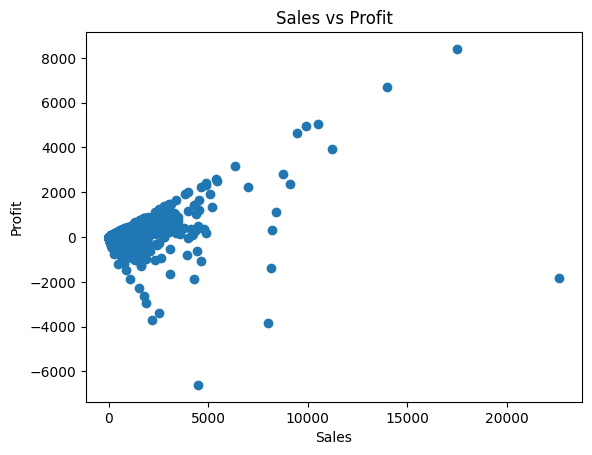

In [31]:
# Relationship (Sales vs Profit)
plt.scatter(df['Sales'], df['Profit'])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

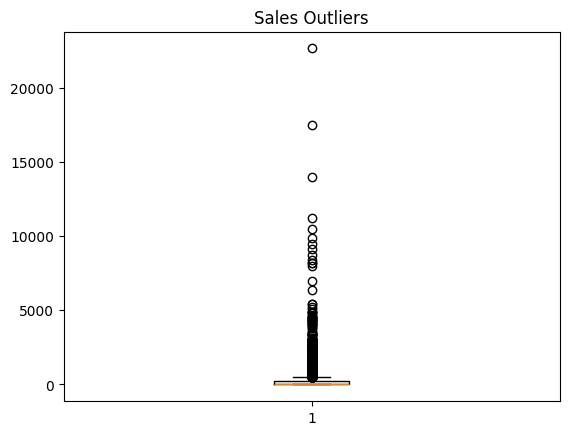

In [32]:
# Outlier Analysis
plt.boxplot(df['Sales'])
plt.title("Sales Outliers")
plt.show()

In [33]:
# Monthly Trend
df.groupby('Month')['Sales'].sum()

,Sales
Month,
1,94924.8356
2,59751.2514
3,205005.4888
4,137762.1286
5,155028.8117
6,152718.6793
7,147238.0970
8,159044.0630
9,307649.9457


In [34]:
# NumPy Custom Computation
df['z_score'] = (df['Sales'] - np.mean(df['Sales'])) / np.std(df['Sales'])

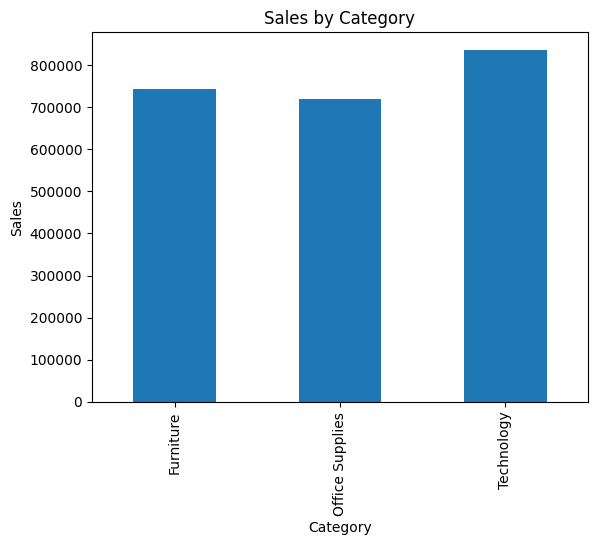

In [35]:
# VISUALIZATION
# Bar Chart
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

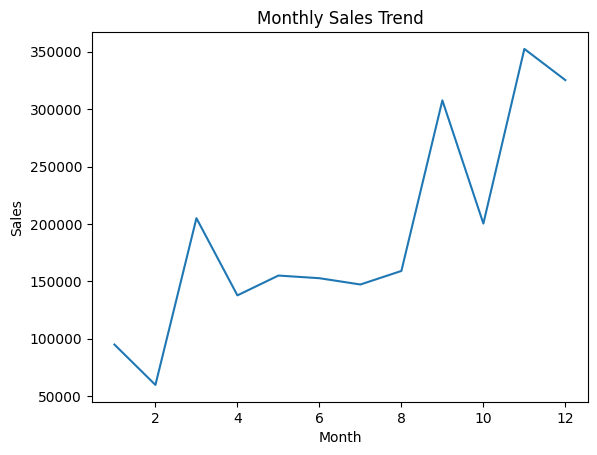

In [36]:
# Line Chart
df.groupby('Month')['Sales'].sum().plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

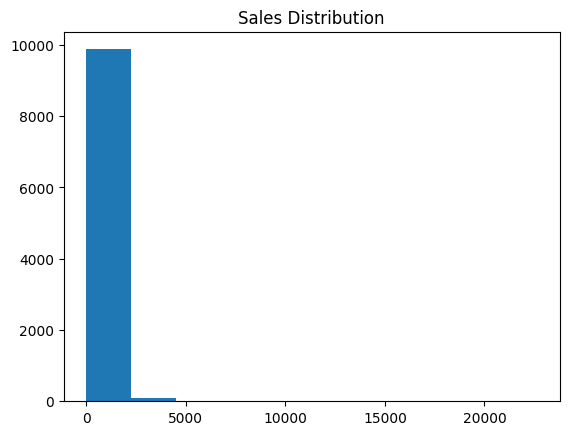

In [37]:
# Histogram
plt.hist(df['Sales'])
plt.title("Sales Distribution")
plt.show()